Experiment 2: Overfitting Analysis and Regularization Techniques

1. Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import pandas as pd

2. Load and Preprocess MNIST

In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


Training data shape: (60000, 784)
Test data shape: (10000, 784)


3. Accuracy Plot Function

In [ ]:
def plot_accuracy(history, title):
    plt.figure(figsize=(6,4))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


4. Baseline MLP Model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8552 - loss: 0.4846 - val_accuracy: 0.9642 - val_loss: 0.1185
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9706 - loss: 0.1007 - val_accuracy: 0.9707 - val_loss: 0.0980
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9827 - loss: 0.0553 - val_accuracy: 0.9746 - val_loss: 0.0875
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9886 - loss: 0.0364 - val_accuracy: 0.9755 - val_loss: 0.0872
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9916 - loss: 0.0276 - val_accuracy: 0.9766 - val_loss: 0.0805
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9931 - loss: 0.0201 - val_accuracy: 0.9770 - val_loss: 0.0848
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9955 - loss: 0.0144 - val_accuracy: 0.9784 - val_loss: 0.0809
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9980 - loss: 0.0074 - val_acc

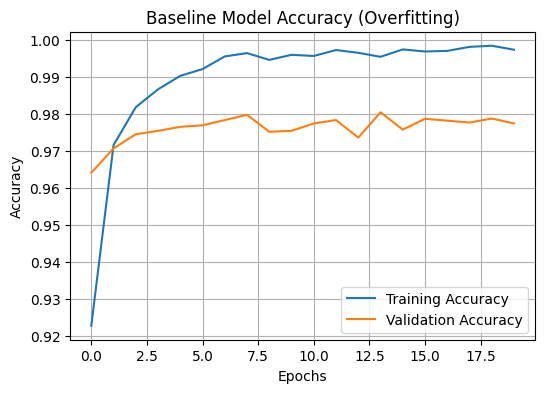

In [ ]:
baseline_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_accuracy(history_baseline, "Baseline Model Accuracy (Overfitting)")



5. BATCH NORMALIZATION MODEL

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8941 - loss: 0.3501 - val_accuracy: 0.9638 - val_loss: 0.1211
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9776 - loss: 0.0737 - val_accuracy: 0.9682 - val_loss: 0.1041
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9883 - loss: 0.0422 - val_accuracy: 0.9718 - val_loss: 0.0956
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9915 - loss: 0.0289 - val_accuracy: 0.9749 - val_loss: 0.0882
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9948 - loss: 0.0195 - val_accuracy: 0.9743 - val_loss: 0.0914
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9949 - loss: 0.0173 - val_accuracy: 0.9758 - val_loss: 0.0880
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9968 - loss: 0.0115 - val_accuracy: 0.9762 - val_loss: 0.0903
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9949 - loss: 0.0164 - val_ac

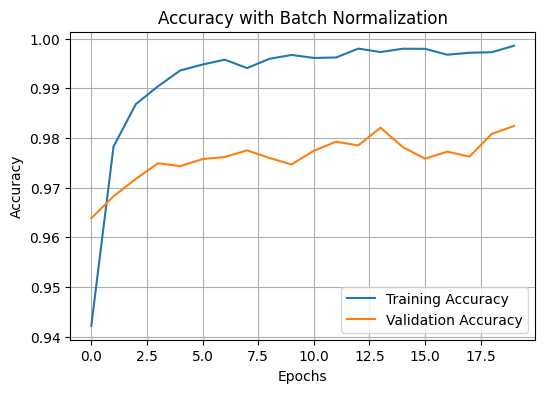

In [ ]:
bn_model = models.Sequential([
    layers.Dense(512, input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(10, activation='softmax')
])

bn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = bn_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_accuracy(history_bn, "Accuracy with Batch Normalization")


6. L2 REGULARIZATION MODEL

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8553 - loss: 1.0706 - val_accuracy: 0.9593 - val_loss: 0.4103
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9599 - loss: 0.3700 - val_accuracy: 0.9681 - val_loss: 0.2737
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9706 - loss: 0.2522 - val_accuracy: 0.9673 - val_loss: 0.2372
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9729 - loss: 0.2200 - val_accuracy: 0.9631 - val_loss: 0.2311
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9752 - loss: 0.1972 - val_accuracy: 0.9695 - val_loss: 0.1991
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9762 - loss: 0.1814 - val_accuracy: 0.9718 - val_loss: 0.2054
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9786 - loss: 0.1719 - val_accuracy: 0.9719 - val_loss: 0.1910
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9793 - loss: 0.1648 - val_acc

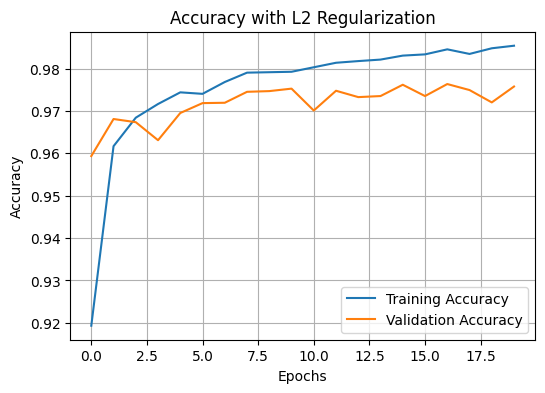

In [ ]:
l2_model = models.Sequential([
    layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(784,)),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

l2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_l2 = l2_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_accuracy(history_l2, "Accuracy with L2 Regularization")

7. DROPOUT MODEL

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7667 - loss: 0.7317 - val_accuracy: 0.9527 - val_loss: 0.1562
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9374 - loss: 0.2044 - val_accuracy: 0.9663 - val_loss: 0.1147
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9551 - loss: 0.1475 - val_accuracy: 0.9694 - val_loss: 0.0984
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9620 - loss: 0.1260 - val_accuracy: 0.9715 - val_loss: 0.0906
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9642 - loss: 0.1105 - val_accuracy: 0.9730 - val_loss: 0.0892
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9720 - loss: 0.0920 - val_accuracy: 0.9759 - val_loss: 0.0813
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9741 - loss: 0.0846 - val_accuracy: 0.9763 - val_loss: 0.0824
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9752 - loss: 0.0770 - val_acc

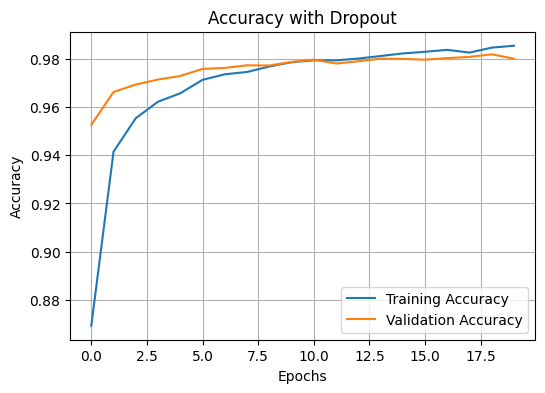

In [ ]:
dropout_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = dropout_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_accuracy(history_dropout, "Accuracy with Dropout")


8. COMPARATIVE TEST ACCURACY TABLE

In [ ]:
results = {
    "Model": [
        "Baseline",
        "Batch Normalization",
        "L2 Regularization",
        "Dropout"
    ],
    "Test Accuracy": [
        baseline_model.evaluate(x_test, y_test, verbose=0)[1],
        bn_model.evaluate(x_test, y_test, verbose=0)[1],
        l2_model.evaluate(x_test, y_test, verbose=0)[1],
        dropout_model.evaluate(x_test, y_test, verbose=0)[1]
    ]
}

df = pd.DataFrame(results)
df["Test Accuracy"] = df["Test Accuracy"].round(4)
df


,Model,Test Accuracy
0,Baseline,0.9790
1,Batch Normalization,0.9821
2,L2 Regularization,0.9789
3,Dropout,0.9827
